# Beckmann rate Data

This workbook contains the code and imports the data to explore the Beckmann hammett plot.

the data being plotted is from "Studies of the Beckmann change. Part IV. Some effects of substitution on the rate of rearrangement of ketoxime picryl ethers. A suggested mechanism of the transformation." Arthur W. Chapman  and  Frederick A. Fidler, *J. Chem. Soc.*, **1936**, 448-453. https://doi.org/10.1039/JR9360000448




## Setup Tools and Read Substituent Data Table

Here the data table for Steric substitutent constants is read in and processed. Also the libraries are imported and any functions defined

In [1]:

####################################################
### Import Libraries and set up global variables ###
####################################################

# Install packages only if needed
# Coogle Colab does not include every Python package
#   
try:                  # if the package exists import it, otherwise install it
    import lmfit
except ImportError:
    !pip -q install lmfit
    import lmfit

try:
    import uncertainties
except ImportError:
    !pip -q install uncertainties
    import uncertainties

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import linregress
from scipy.optimize import curve_fit

import uncertainties as un
from uncertainties import unumpy as unp

from matplotlib.ticker import FormatStrFormatter
from scipy.stats import t

from pathlib import Path

Path("plots").mkdir(exist_ok=True)
#Path("plots/stacking").mkdir(exist_ok=True)
#Path("plots/single").mkdir(exist_ok=True)
#Path("plots/fits").mkdir(exist_ok=True)

#Path("data").mkdir(exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

#if IN_COLAB and not Path("data/3c.csv").exists():
#    !wget -q -O data/3c.csv https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/notebooks/M11_Plot_Recommendations/3c.csv

if IN_COLAB and not Path("tufte.mplstyle").exists():
    !wget -q https://raw.githubusercontent.com/blinkletter/Chem4410Webbook/main/book/styles/tufte.mplstyle
if IN_COLAB and not Path("data").exists():
    !wget -q https://raw.github.com/blinkletter/Chem4410Webbook/main/book/notebooks/M33_Beckmann/data.zip
    !unzip -q data.zip

github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"

plt.rcdefaults()


style_file = "tufte.mplstyle"
#style_file = "S2_classic2.mplstyle"


#################################################################
### a function to fill in sigma for empty spaces in s+ and s- ###
#################################################################

def fill_sigma(df):     
    for z in df.index:
        if np.isnan(df.loc[z,"s_plus"]):
            df.loc[z,"s_plus"] = df.loc[z,"sigma"]
        if np.isnan(df["s_minus"][z]):
            df.loc[z,"s_minus"] = df.loc[z,"sigma"]
    return(df)


In [2]:
################################################################################
### Read data set. The fields are separated by commas; comments are enabled  ###
################################################################################

#LFER_file = "Taft_Es_Williams.csv"   
#LFER_file = "LFER_HanschLeoTaft.csv"   
LFER_file = "LFER_Williams.csv"   ### This had values for a few ortho substituents

data_set = pd.read_csv(github_location_LFER_tables + LFER_file,
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 

#display(data_set)

########################################################
### Fill across sigma values and select substituents ###
########################################################

data_set=fill_sigma(data_set)
#display(data_set)

###############################
### Remove unneeded columns ###
###############################

if LFER_file == "LFER_HanschLeoTaft.csv":
    data_set.drop(labels = ["TABLE V", "TABLE I"],      #Trim "LFER_HanschLeoTaft.csv" data
    axis = 1,
    inplace = True)
elif LFER_file == "LFER_Williams.csv":
    data_set.drop(labels = ["Page"],                   #Trim "LFER_Williams.csv"" data
    axis = 1,
    inplace = True)
else:
    print("ERROR: No filename")

#######################################
### Sort by Steric Size and display ###
#######################################

#data_set.sort_values(by=['sigma'], inplace=True)
#data_set.sort_values(by=["E'(s)"], inplace=True)

display(data_set)

,sigma,s_plus,s_minus
Substituent,,,
m-Br,0.39,0.39,0.39
p-Br,0.23,0.15,0.25
m-C6H5,0.06,0.06,0.06
p-C6H5,-0.01,0.02,-0.18
m-CCCH3,0.10,0.10,0.10
...,...,...,...
p-C(CH3)3,-0.20,-0.26,-0.13
m-C(CH3)3,-0.10,-0.10,-0.10
"3,5-CH3",-0.12,-0.12,-0.12


## Read Experimental Data for Acid Hydrolysis
Here the data from the publication is read in. It had been saved in a csv file. the data is from...

"Studies of the Beckmann change. Part IV. Some effects of substitution on the rate of rearrangement of ketoxime picryl ethers. A suggested mechanism of the transformation." Arthur W. Chapman  and  Frederick A. Fidler, *J. Chem. Soc.*, **1936**, 448-453. https://doi.org/10.1039/JR9360000448

In [3]:
############################################
### Read in data from literature example ###
############################################

datafile = "data/NotUsed/21-Beckmann_5.csv"

Beckmann_data = pd.read_csv(datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 index_col="Substituent", 
                 comment = "#") 
#display(Beckmann_data.head())

###
### Note: The values of the rate constants are relative ratyes k_H/k_X
###

###############################
### Remove unneeded columns ###
###############################

#Beckmann_data.drop(labels = ["Name", "ref"], axis = 1, inplace = True)  # remove unwanted columns

###############################
### calculations            ###
###############################

Beckmann_data["log_kX/kH anti"] = -np.log10(Beckmann_data["kH/kX anti"])
Beckmann_data["log_kX/kH syn"] = -np.log10(Beckmann_data["kH/kX syn"])

display(Beckmann_data)


,kH/kX anti,kH/kX syn,log_kX/kH anti,log_kX/kH syn
Substituent,,,,
H,1.00,1.00,-0.000000,-0.000000
p-Cl,5.00,2.45,-0.698970,-0.389166
p-CH3,0.13,0.41,0.886057,0.387216


## Combine Data Sets

Both data sets are indexed by "Substituent". The code below will combine the two data sets according to "Substituent" and take the intersection of the sets.

## Calculations

We need the log of the rate. Also we will convert the rate to SI units. The current units are in $10^{-4} s^{-1}$. We will convert to $s^{-1}$ by multiplying by $10^4$.


In [4]:
##################################################
### Combine data sets using the index column.  ###
### Data lines that share an index column will ###
### be combined, all other ignored.            ###
##################################################

combined_data = pd.concat([Beckmann_data, data_set], axis=1, join="inner")
#display(combined_data_acid)

#########################################################################
### Perform calculations on columns and add new columns with results  ###
#########################################################################

#combined_data["k"] = combined_data["k"] * 10**(-6)
##combined_data["log_k"] = np.log10(combined_data["k"])

#combined_data.drop(labels = ["o-NO2","o-Cl","o-CH3"], axis = 0, inplace = True)  # remove the "o-NO2" data point.
#combined_data.drop(labels = ["p-OH"], axis = 0, inplace = True)  # remove the "o-NO2" data point.

display(combined_data)


,kH/kX anti,kH/kX syn,log_kX/kH anti,log_kX/kH syn,sigma,s_plus,s_minus
Substituent,,,,,,,
H,1.00,1.00,-0.000000,-0.000000,0.00,0.00,0.00
p-Cl,5.00,2.45,-0.698970,-0.389166,0.23,0.11,0.19
p-CH3,0.13,0.41,0.886057,0.387216,-0.14,-0.31,-0.17


## Plot and Curve Fits

The code below will extract the x,y data for our plots and perform the linear fit to the hammett equation. I have decided to put boths ets of data on the same plot for comparison sake. You will see exactly what i have done by examining the code.

anti (open circles)
slope  = -4.01
intercept = -0.011
RSQ = 1.000
LinregressResult(slope=np.float64(-4.00880141804123), intercept=np.float64(-0.011132478211707764), rvalue=np.float64(-0.9999258683965015), pvalue=np.float64(0.007751745411336626), stderr=np.float64(0.048815235131246346), intercept_stderr=np.float64(0.007947793909057888))
syn (open circles)
slope  = -2.02
intercept = 0.001
RSQ = 1.000
LinregressResult(slope=np.float64(-2.0165495559835596), intercept=np.float64(0.0013665691945609162), rvalue=np.float64(-0.9999953525767384), pvalue=np.float64(0.0019408921463706828), stderr=np.float64(0.006147966953439141), intercept_stderr=np.float64(0.0009663396804625156))


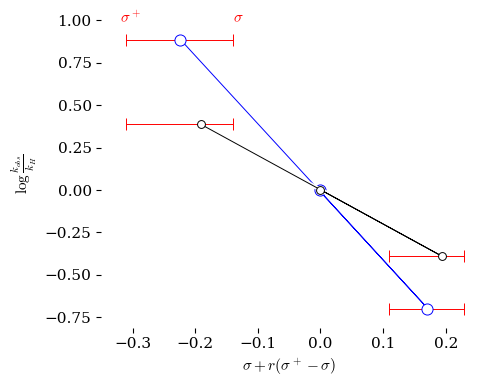

In [5]:
from scipy.stats import linregress
import matplotlib

#####################################################
### Get series of data to plot from the dataframe ###
#####################################################
y_anti =  combined_data["log_kX/kH anti"]
y_syn =  combined_data["log_kX/kH syn"]

##################################################
### Setup a figure with two plots side-by-side ###
### and choose a stylesheet                    ###
##################################################

plt.style.use(style_file)        

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

#########################################
### Plot the data and the line fit.   ###
#########################################

y = y_anti
r = 0.5
x = combined_data["sigma"]+r*(combined_data["s_plus"]-combined_data["sigma"])  # Yukawa Tsuno

#ax.scatter(x,y, s=64, color="white",  edgecolors = "none", zorder=2)
#ax.scatter(x,y, s=32, color="black",  edgecolors = "none", zorder=2)
ax.scatter(x,y, s=64, color="white",  edgecolors = "blue", alpha = 1, zorder=2, linewidths=0.7)

if True:   # Flag to run or not. True = run this section, False = skip it
    linfit = linregress(x,y)
    fit = linfit.slope * x + linfit.intercept
    ax.plot(x, fit, color='blue', zorder=1, linewidth=0.7)

    #####################################
    ### Print the line fit parameters ###
    #####################################
    print("anti (open circles)")
    print(f"slope  = {linfit.slope:0.2f}")
    print(f"intercept = {linfit.intercept:0.3f}")
    print(f"RSQ = {(linfit.rvalue**2):0.3f}")
    print(linfit)

if True:   #Set to True to see bounds of sigma and sigma plus values
    x1 = combined_data["sigma"]
    x2 = combined_data["s_plus"]

    ax.text(x1.iloc[2], y.iloc[2]+0.10, r"$\sigma$", color="red")  # Label for sigma values
    ax.text(x2.iloc[2]-0.01, y.iloc[2]+0.10, r"$\sigma^+$", color = "red")
    data = zip(x1, x2, y)

    for x1, x2, y in data:
        if x1 != x2:

            #ax.scatter(x1,y, s=64, marker="|", color="white", zorder=1)
            #ax.scatter(x2,y, s=64, marker="|", color="white", zorder=1)
            #ax.hlines(y=y, xmin=x2, xmax=x1, colors='white', linestyles='solid', zorder=1, linewidth=2)
        
            ax.scatter(x1,y, s=64, marker="|", color="red", zorder=1, linewidths=0.7)
            ax.scatter(x2,y, s=64, marker="|", color="red", zorder=1, linewidths=0.7)
            ax.hlines(y=y, xmin=x2, xmax=x1, colors='red', linestyles='solid', zorder=1, linewidth=0.7)

y = y_syn
r = 0.3
x = combined_data["sigma"]+r*(combined_data["s_plus"]-combined_data["sigma"])  # Yukawa Tsuno


#ax.scatter(x,y, s=64, color="white",  edgecolors = "none", zorder=5)
ax.scatter(x,y, s=32, color="white",  edgecolors = "black", zorder=5, linewidths=0.7)

if True:   # Flag to run or not. True = run this section, False = skip it
    linfit = linregress(x,y)
    fit = linfit.slope * x + linfit.intercept
    ax.plot(x, fit, color='white', zorder=4, linewidth=3)
    ax.plot(x, fit, color='black', zorder=4, linewidth=0.7)

    #####################################
    ### Print the line fit parameters ###
    #####################################
    print("syn (open circles)")
    print(f"slope  = {linfit.slope:0.2f}")
    print(f"intercept = {linfit.intercept:0.3f}")
    print(f"RSQ = {(linfit.rvalue**2):0.3f}")
    print(linfit)

if True:   #Set to True to see bounds of sigma and sigma plus values
    x1 = combined_data["sigma"]
    x2 = combined_data["s_plus"]
    data = zip(x1, x2, y)

    for x1, x2, y in data:
        if x1 != x2:

            #ax.scatter(x1,y, s=64, marker="|", color="white", zorder=4)
            #ax.scatter(x2,y, s=64, marker="|", color="white", zorder=4)
            #ax.hlines(y=y, xmin=x2, xmax=x1, colors='white', linestyles='solid', zorder=4, linewidth=2)
        
            ax.scatter(x1,y, s=64, marker="|", color="red", zorder=4, linewidths=0.7)
            ax.scatter(x2,y, s=64, marker="|", color="red", zorder=4, linewidths=0.7)
            ax.hlines(y=y, xmin=x2, xmax=x1, colors='red', linestyles='solid', zorder=4, linewidth=0.7)

############################
### Set labels and scale ###
############################

#xlabel_string = r"$\sigma$"
#xlabel_string = r"$\sigma^+$"
#xlabel_string = r"$\sigma + r(\sigma^+-\sigma)$, $r =$ "+f"{r:0.2f}"
xlabel_string = r"$\sigma + r(\sigma^+-\sigma)$"

ax.set(
#    title="Hammett Plot",       
          ylabel=r"$\log{\frac{k_{obs}}{k_H}}$", 
          xlabel=xlabel_string,                
          xlim=[-.35,.25],                  
#          ylim=[-6,-1]
         )

if False:    # Flag to run or not. True = run this section, False = skip it
    for name,x_place,y_place in zip(list(combined_data.index),x,y):
        plt.annotate(name, # this is the text
                    (x_place,y_place), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(30,0), # distance from text to points (x,y)
                    ha='left') # horizontal alignment can be left, right or center



fig.savefig("plots/figure12.pdf")   # use this to save the figure in PDF format
plt.show()                 # output the combined plot plots



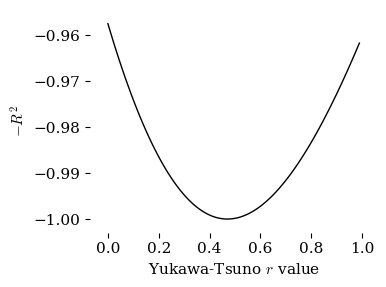

The optimal value for r is 0.471 for rsq = -1.00000


In [6]:
from scipy.optimize import minimize_scalar

df = combined_data

y = y_anti
#y = y_syn

def RSQ_function(r):    # returns the RSQ for linefits using the given Yukawa-Tsuno r factor
    x = df["sigma"]+r*(df["s_plus"]-df["sigma"])
    linfit = linregress(x,y)
    return -(linfit.rvalue**2)


##########################################################
### Plot the value of -RSQ as the value of r is varied ###
##################################################

plt.style.use(style_file)        

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4,3))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   
ax.set(ylabel=r"$-R^2$", 
       xlabel=r"Yukawa-Tsuno $r$ value")

rsq_range=[]
r_range = np.arange(0,1,0.01)
for r in r_range:
    rsq = RSQ_function(r)
    rsq_range.append(rsq)
    
ax.plot(r_range,rsq_range)

fig.savefig("plots/figure12opt.pdf")   # use this to save the figure in PDF format
plt.show()

##################################################
### Determine optimal r value to minimize -RSQ ###
##################################################

r_opt = minimize_scalar(RSQ_function)
print(f"The optimal value for r is {r_opt['x']:0.3f} for rsq = {r_opt['fun']:0.5f}")

In [7]:
x = df["sigma"]+0.325*(df["s_plus"]-df["sigma"])

"Kinetic Study of Beckmann rearrangement of Anti Benzaldoximes in Perchloric acid." A.S.P. Azzuoz, B.O. Kashmola, *Iraqi National Journal Of Chemistry*, **2011**, *41*.  https://www.iasj.net/iasj/download/4df054d1d9589785